## Assignment 1 

This assignment is based on the video discussed in module 1.

John Rauser ( 2014). Statistics Without the Agonizing Pain. Strata Hadoop 2014. Retrieved from https://www.youtube.com/watch?v=5Dnw46eC-0o

(Source: https://www.youtube.com/watch?v=5Dnw46eC-0o )




 
  
 

## Learning outcomes

- Use code to work with data
- Calculate basic statistical measures 
- Implement a data simulation by using resampling 


**Question**

1. Using the dataset from the video ( _mosquitos_data.csv_) in the folder, write Python code to:

    - Create side-by-side boxplots for the number of mosquitos in each group ( _beer vs water) 
    - What does the graph reveal about the data for both groups?  Is there an association between beer       consumption and attractiveness to mosquitos.
    - Calculate basic statistics measures for each group: Mean, median, standard deviation and explain the numbers.

2. Write code to implement the data simulation demonstrated in the above mentioned video.  Calculate the probability of obtaining the experiment outcome assuming no association between beer consumption.

## Hints

- Use pandas, matplotlib, or seaborn to plot boxplots in Python. 
- Label the graphs wherever applicable e.g, title, legend, units etc.





### Preparation

First of all, import the required libraries, read in the CSV file and take a quick peek at the data.

In [1]:
# Import the libraries.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random


In [2]:
# Read the CSV file and take a look at the first five records.

df = pd.read_csv("mosquitos_data.csv")
df.head()

,Response,Treatment
0,27,Beer
1,20,Beer
2,21,Beer
3,26,Beer
4,27,Beer


In [3]:
print("There are", df.shape[0], "rows in the DataFrame.")
print("There are", df[(df['Treatment'] == 'Beer')].shape[0], "Beer rows.")
print("There are", df[(df['Treatment'] == 'Water')].shape[0], "Water rows.")

There are 43 rows in the DataFrame.
There are 25 Beer rows.
There are 18 Water rows.


### Side-by-Side Boxplots Comparison

Now, create side-by-side boxplots to show the distribution of data.  The data will show how many mosquitos were attracted to those that drank beer vs those that drank water.

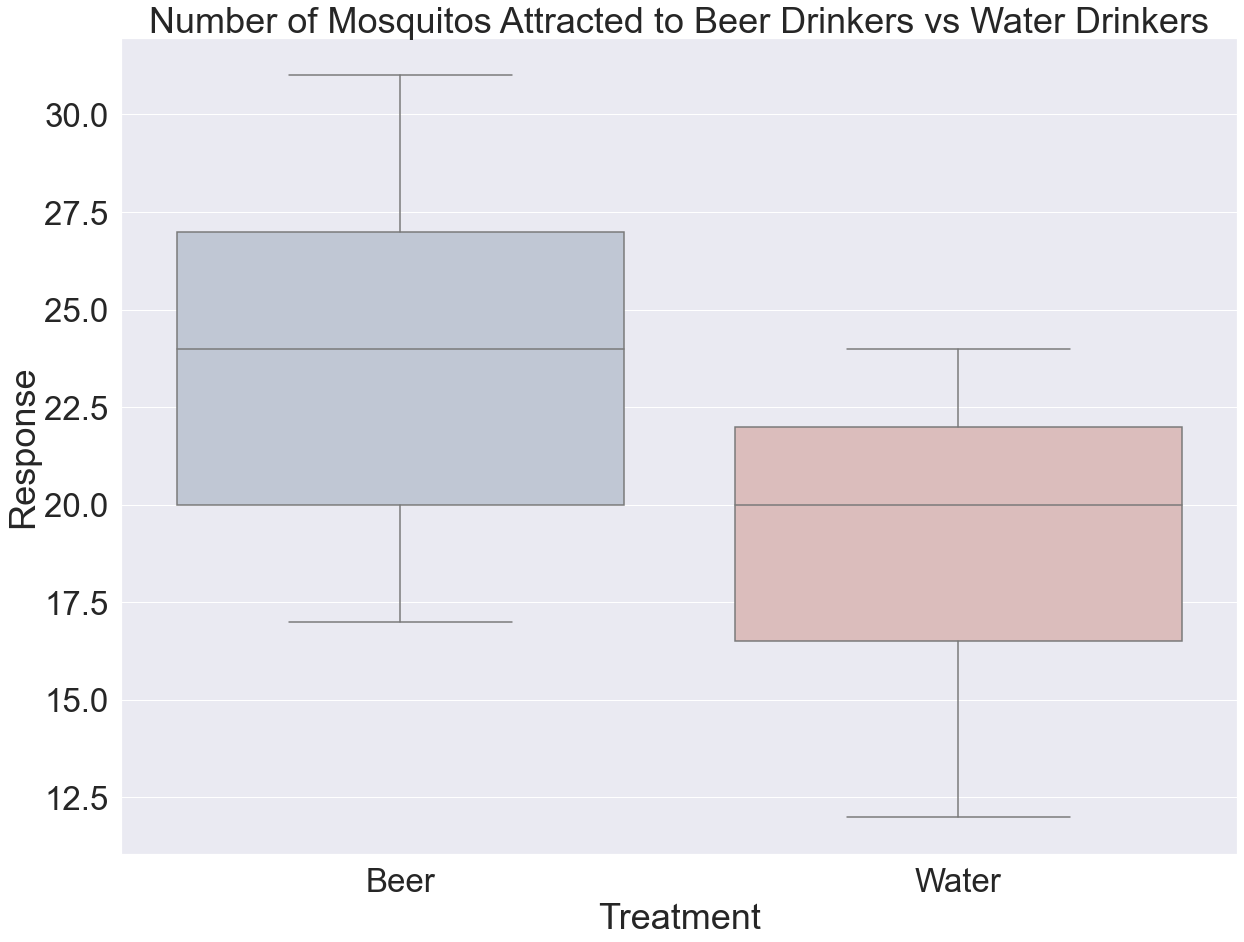

In [4]:
graph_title = "Number of Mosquitos Attracted to Beer Drinkers vs Water Drinkers"

# Set the style and font size to be more readable.

plt.style.use('seaborn')
sns.set(font_scale=3)

# Create the boxplot.

fig, ax = plt.subplots(figsize=(20, 15))
g = sns.boxplot(x="Treatment", y="Response", data=df, whis=1.5, palette="vlag", showfliers=True).set(title=graph_title)


From the above boxplot, the range of data for _mosquitos attracted_ is larger for the Beer group than the Water group.  The minimum and maximum numbers for the Beer group are larger than those for the Water group.  The median (the line within each box) is also larger for the Beer group than the Water group.  Lastly, the 25th and 75th quartiles (the lower and upper box limits, respectively) are also larger for the Beer group than the Water group.

Therefore, from this sample size and the values of the box plot, there appears to be a correlation between Beer consumption and the number of mosquitos that are attracted compared to those drinking Water.

Now, let's calculate the mean, median and standard deviation values for the two Treatment groups.


In [5]:
# Calculate the means.

beer_mean  = df[(df['Treatment'] == 'Beer')]['Response'].mean()
water_mean = df[(df['Treatment'] == 'Water')]['Response'].mean()

beer_water_mean_delta = round((beer_mean - water_mean), 1)

# Calculate the medians.

beer_median  = df[(df['Treatment'] == 'Beer')]['Response'].median()
water_median = df[(df['Treatment'] == 'Water')]['Response'].median()

# Calculate the standard deviations.

beer_std  = df[(df['Treatment'] == 'Beer')]['Response'].std()
water_std = df[(df['Treatment'] == 'Water')]['Response'].std()

print('Beer mean =\t%.1f' % beer_mean, '\tand Water mean =\t%.1f' % water_mean)
print('Beer median =\t%.1f' % beer_median, '\tand Water median =\t%.1f' % water_median)
print('Beer std  =\t%.1f' % beer_std, '\tand Water std =\t\t%.1f' % water_std)

# Ensure that the delta between the beer and water groups is the same as in the video
# since it is using the same data set.

print('\nUsing the means, people drinking beer attracted', beer_water_mean_delta, 'more mosquitos than those that drank water.')

assert beer_water_mean_delta == 4.4, "The mean delta between the beer and water group is not 4.4."


Beer mean =	23.6 	and Water mean =	19.2
Beer median =	24.0 	and Water median =	20.0
Beer std  =	4.1 	and Water std =		3.7

Using the means, people drinking beer attracted 4.4 more mosquitos than those that drank water.


The **mean** values, or average number of mosquitos attracted to each group, is larger for the Beer group than the Water group.  Therefore, using this measurement, more mosquitos were attracted to the Beer group than the Water group.  In fact, the Beer group attracted an average of 4.4 more mosquitos for this data set.

The **median** value, which indicates the half-way point where half the values in the data set are higher and half the values are smaller, is larger for the Beer group than the Water group.  The median for the Beer group is 4 mosquitos more than the Water group.  The medians for both groups are also close, but not quite equal, to the means for their groups.  This shows that the data is slightly skewed which the boxplots show through their ranges.  As the median shows the central tendency of the data, it also reinforces that the Beer group attracted 4 more mosquitos than the Water group. 

Lastly, the **standard deviation** indicates the average distance each data element is from the mean.  Once again, the Beer group had the larger value but not by much (0.4).  This shows that the Beer group had a slightly larger range of _number of mosquitos attracted_ than the Water group which is a bit more compact.  Once again, this is illustrated in the boxplots through their ranges.  It also looks like most data is within 2 standard deviations of the means for both data sets which would suggest the data is normally distributed.

### Data Simulation

Let's define a couple of functions to help with the data simulation.

In [6]:
def get_dataframe_sample(orig_df, column_name, column_value, sample_size=2):

    """Get a random sample of rows from the DataFrame.

    Parameters
    ----------
    orig_df : DataFrame
        The DataFrame from which to get the random sample.
    column_name : String
        The column name in which to search.
    column_value : String
        The value to search for in the column.
    sample_size : int, optional
        The number of rows to extract.

    Returns
    -------
    DataFrame
        A subset of the original DataFrame containing the random sample of rows.

    Examples
    --------
    >>> water_df = get_dataframe_sample(df, 'Treatment', 'Water', random_num)
    """
    
    # Return a DataFrame containing a random sample of values from the base DataFrame
    # where the column name contains the value.
    
    return orig_df[orig_df[column_name].str.contains(column_value)].sample(n=sample_size)

In [7]:
def switch_dataframe_value(orig_df, replace_df, column_id, column_value):

    """Modify values in a DataFrame column with a specific value for those rows specified
    by another DataFrame.

    Parameters
    ----------
    orig_df : DataFrame
        The DataFrame to modify.
    replace_df : DataFrame
        The DataFrame from which to get the rows to modify.
    column_id : int
        The column ID to update.
    column_value : String
        The new value for the column.

    Returns
    -------
    DataFrame
        An updated original DataFrame.

    Examples
    --------
    >>> df = switch_dataframe_value(df, water_df, 1, 'Beer')
    """
    
    # Iterate over the rows in the replacement DataFrame and change the column
    # values in the original DataFrame with the specified value.
    
    for i, row in replace_df.iterrows():
        orig_df.iloc[i, column_id] = column_value
        
    return orig_df

Create the data simulation by conducting 50,000 trials of shuffling a random number of data values between the two sets, calculating the means and storing the deltas between the means of each group.

In [8]:
# Create a blank DataFrame to hold the Beer and Water mean deltas.

mean_df = pd.DataFrame(columns = ['Delta Between Means of Each Group'])
mean_df['Delta Between Means of Each Group'] = pd.to_numeric(mean_df['Delta Between Means of Each Group'], downcast='float')

# Conduct the trials.

trials = 50000

for j in range(trials):
    
    # Create a random number of data values to shuffle (from 1 to 10).
    
    random_num = random.randint(1, 10)
    
    # Create a dataframe with the number of data values to shuffle.
    
    water_df = get_dataframe_sample(df, 'Treatment', 'Water', random_num)
    beer_df  = get_dataframe_sample(df, 'Treatment', 'Beer', random_num)
    
    # Switch the dataframe values.
    
    df = switch_dataframe_value(df, water_df, 1, 'Beer')
    df = switch_dataframe_value(df, beer_df, 1, 'Water')
    
    # Calculate the new means for this trial.
    
    trial_beer_mean  = df[(df['Treatment'] == 'Beer')]['Response'].mean()
    trial_water_mean = df[(df['Treatment'] == 'Water')]['Response'].mean()
    
    # Calculate the delta between the means and add it to the dataframe.
    
    beer_water_mean_diff = trial_beer_mean - trial_water_mean
    
    new_row = pd.DataFrame({'Delta Between Means of Each Group' : round(beer_water_mean_diff, 1)}, index=[0])
    mean_df = pd.concat([new_row, mean_df.loc[:]]).reset_index(drop=True)
    
    
# As a check, ensure that the number of elements in the dataframe match the number of trials.

print ("The size of the Mean Delta dataframe (", mean_df.shape[0], ") " \
       "should be the same as the number of trials (", trials, ")")

assert mean_df.shape[0] == trials , "The dataframe size is not equal to the number of trials."

print ("Good!")

The size of the Mean Delta dataframe ( 50000 ) should be the same as the number of trials ( 50000 )
Good!


### Data Visualization

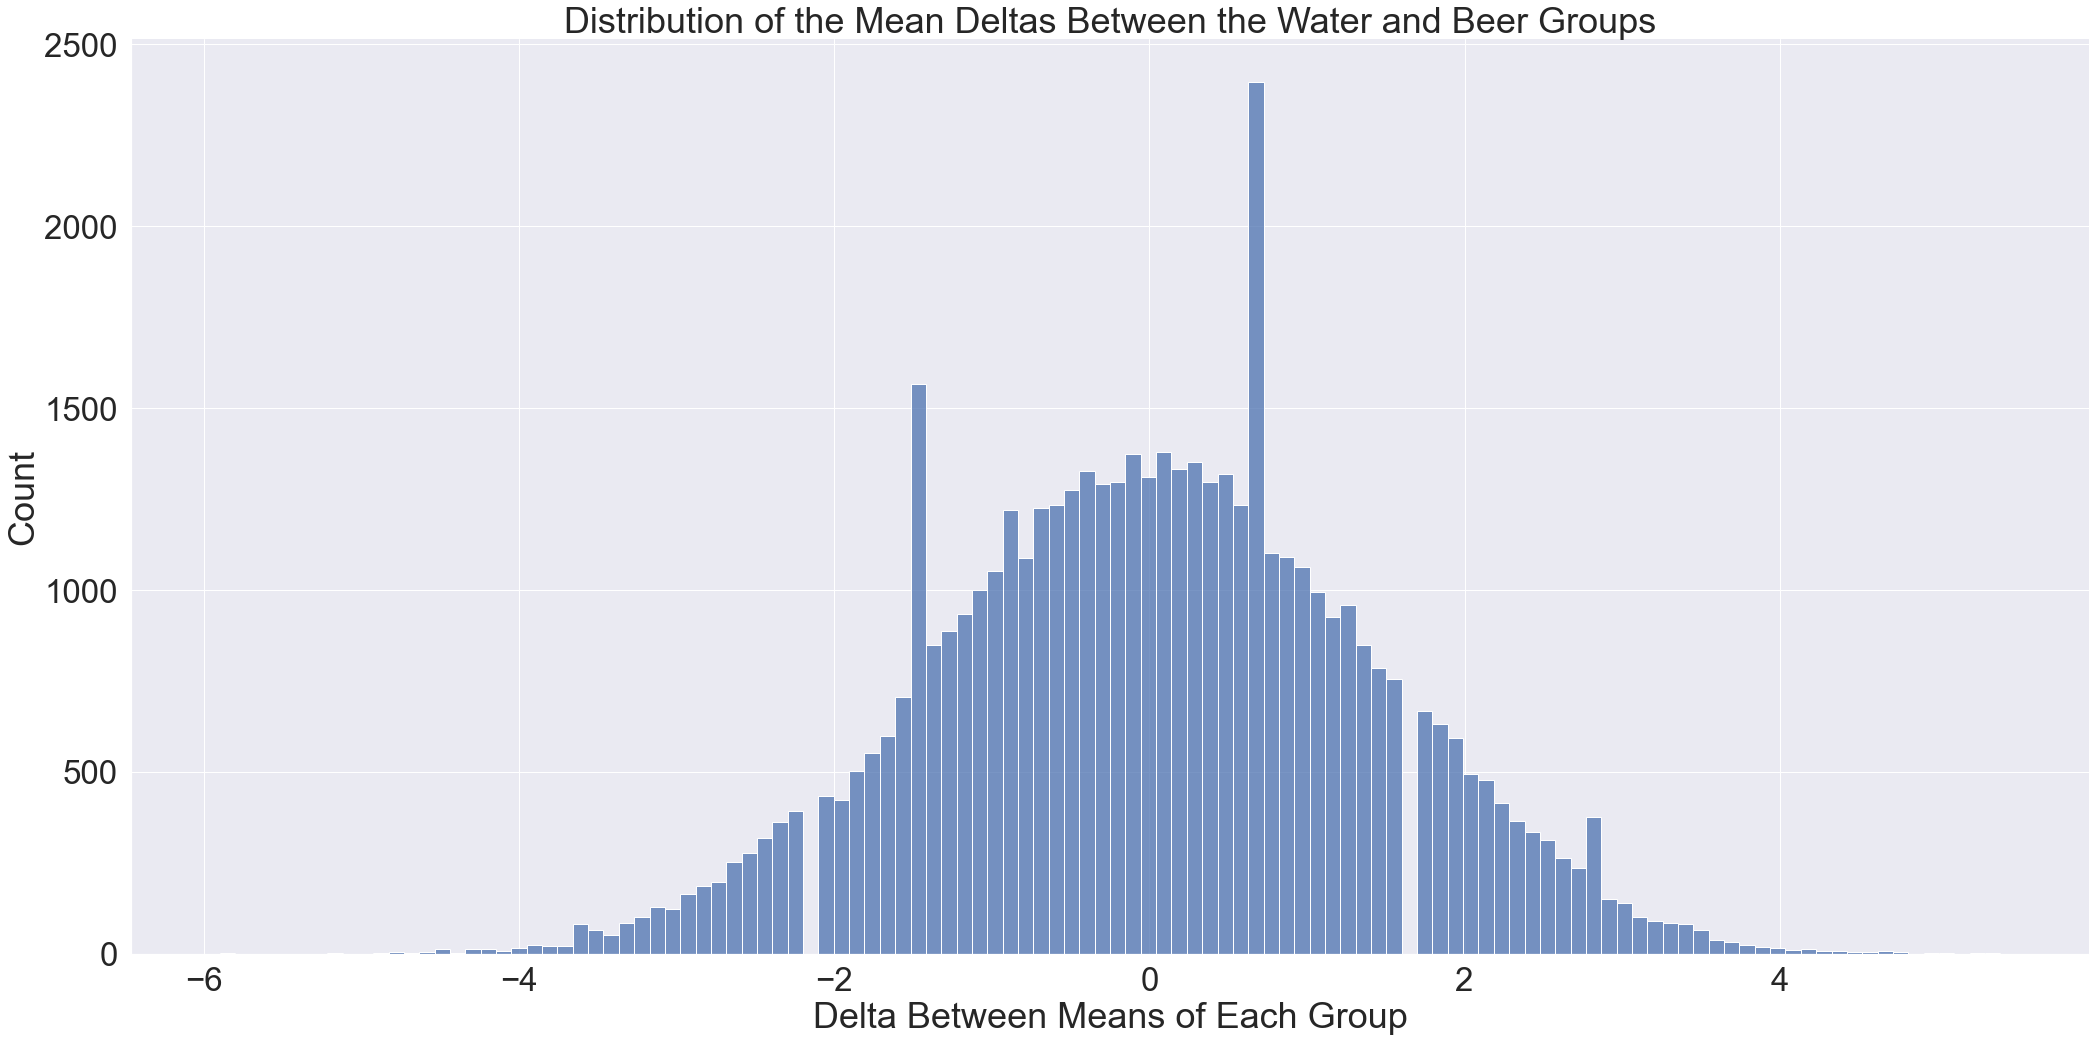

In [9]:
# Create a distribution graph of the mean deltas.

graph_title = "Distribution of the Mean Deltas Between the Water and Beer Groups"

sns.set_style('darkgrid')
sns.displot(mean_df['Delta Between Means of Each Group'], height=15, aspect=2).set(title=graph_title)

### Analysis

In [10]:
# Calculate how many times the original experiment's beer-water mean delta appears in the
# data set as well as the % of getting a value this large.

bwmd_num = mean_df[(mean_df['Delta Between Means of Each Group'] == beer_water_mean_delta)].shape[0]
bwmp_num = mean_df[(mean_df['Delta Between Means of Each Group'] >= beer_water_mean_delta)].shape[0]

print("The original beer and water mean delta (", beer_water_mean_delta, ") appears", bwmd_num, "time(s) in the sample set.")
print("A value this large only occurs", bwmp_num, "times in the sample set.")

print("\nThe probability of getting a value this large, if there was no association between beer consumption and attracting mosquitos is %.5f" % (bwmp_num / trials), '%')


The original beer and water mean delta ( 4.4 ) appears 9 time(s) in the sample set.
A value this large only occurs 38 times in the sample set.

The probability of getting a value this large, if there was no association between beer consumption and attracting mosquitos is 0.00076 %


After running the data simulation through 50,000 trials, the majority of the deltas between the means of each group are between -1 and 1.  In fact, the original beer and water mean delta of 4.4 only appears 9 times.  The probability of getting a value as large as this, if there was no association between beer consumption and attracting mosquitos, is < 1%.

### Conclusion: 

The initial experiment showed that the Beer group attracted an average of 4.4 more mosquitos than those that drank water.  After running a data simulation of 50,000 trials where an assumption was made that there is no association between beer consumption and attracting mosquitos, the probability of getting a value as large as the orginal 4.4 value (the mean delta between the beer and water groups) is < 1%.  Therefore, it can be concluded that this isn't a random event and there is an association between beer consumption and attracting mosquitos.